Using our MVHumanNet dataloader, we can get our cropped images without much hassle.

In this case, we first test on the consistent human case with no random cropping.

In [1]:
%load_ext autoreload
%autoreload 2


In [ ]:
# MVHN using dataset_mvhn.py (THuman format wrapper)
from src.dataset.dataset_mvhn import DatasetMVHN, DatasetMVHNCfg
from torch.utils.data import DataLoader

NUM_INPUT_IMGS = 3
NUM_TEST_IMGS  = 4  # for ease of use within the notebook

# only 3 will be used for training, but we supply more to 'split' into the test images

def expand_only_include(only_include):
    if isinstance(only_include, str): # in the format ex: "100001-102000,102020-104000"
        only_include = only_include.split(",")
        expanded_includes = []
        for subrange in only_include:
            start, end = [int(num) for num in subrange.split("-")]
            print(start, end)
            expanded_includes.extend([str(i).zfill(6) for i in range(start, end + 1)])
        return expanded_includes
    else:
        return only_include

# Create configuration
cfg = DatasetMVHNCfg(
    root_dir="/workspace/datasetvol/mvhuman_data/mv_captures",
    num_images=NUM_INPUT_IMGS + NUM_TEST_IMGS,
    step_size=60,
    path_to_train_json="/workspace/datasets/mvhn/mvhn_train.json",
    path_to_val_json="/workspace/datasets/mvhn/mvhn_val.json",
    path_to_test_json="/workspace/datasets/mvhn/mvhn_test.json",
    preload_path="/workspace/datasetvol/mvhuman_data/preload_paths/shards/",
    iclight_dataset_path="/workspace/datasetvol/mvhuman_data/relit_images",
    # infu_dataset_path="/workspace/datasetvol/mvhuman_data/inconsistent_images",
    arcface_embeddings_dir="/workspace/datasetvol/mvhuman_data/arcface_embeddings",
    use_sapiens_conditioning=[],
    random_crop=False,
    maximal_crop=True,
    crop_padding=60,
    use_inconsistent=False,
    random_crop_prob=0.0,
    target_shape=(256,256),
    load_template_uv=True,  # Set to True if you need template data
    load_da_pose=False,
    load_lbs_weights=False,
)

# Create dataset
dataset = DatasetMVHN(cfg, stage="val")

loader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=0)

100001 104500
100602 100995


In [3]:
len(dataset)

21571

In [61]:
batch = next(iter(loader))

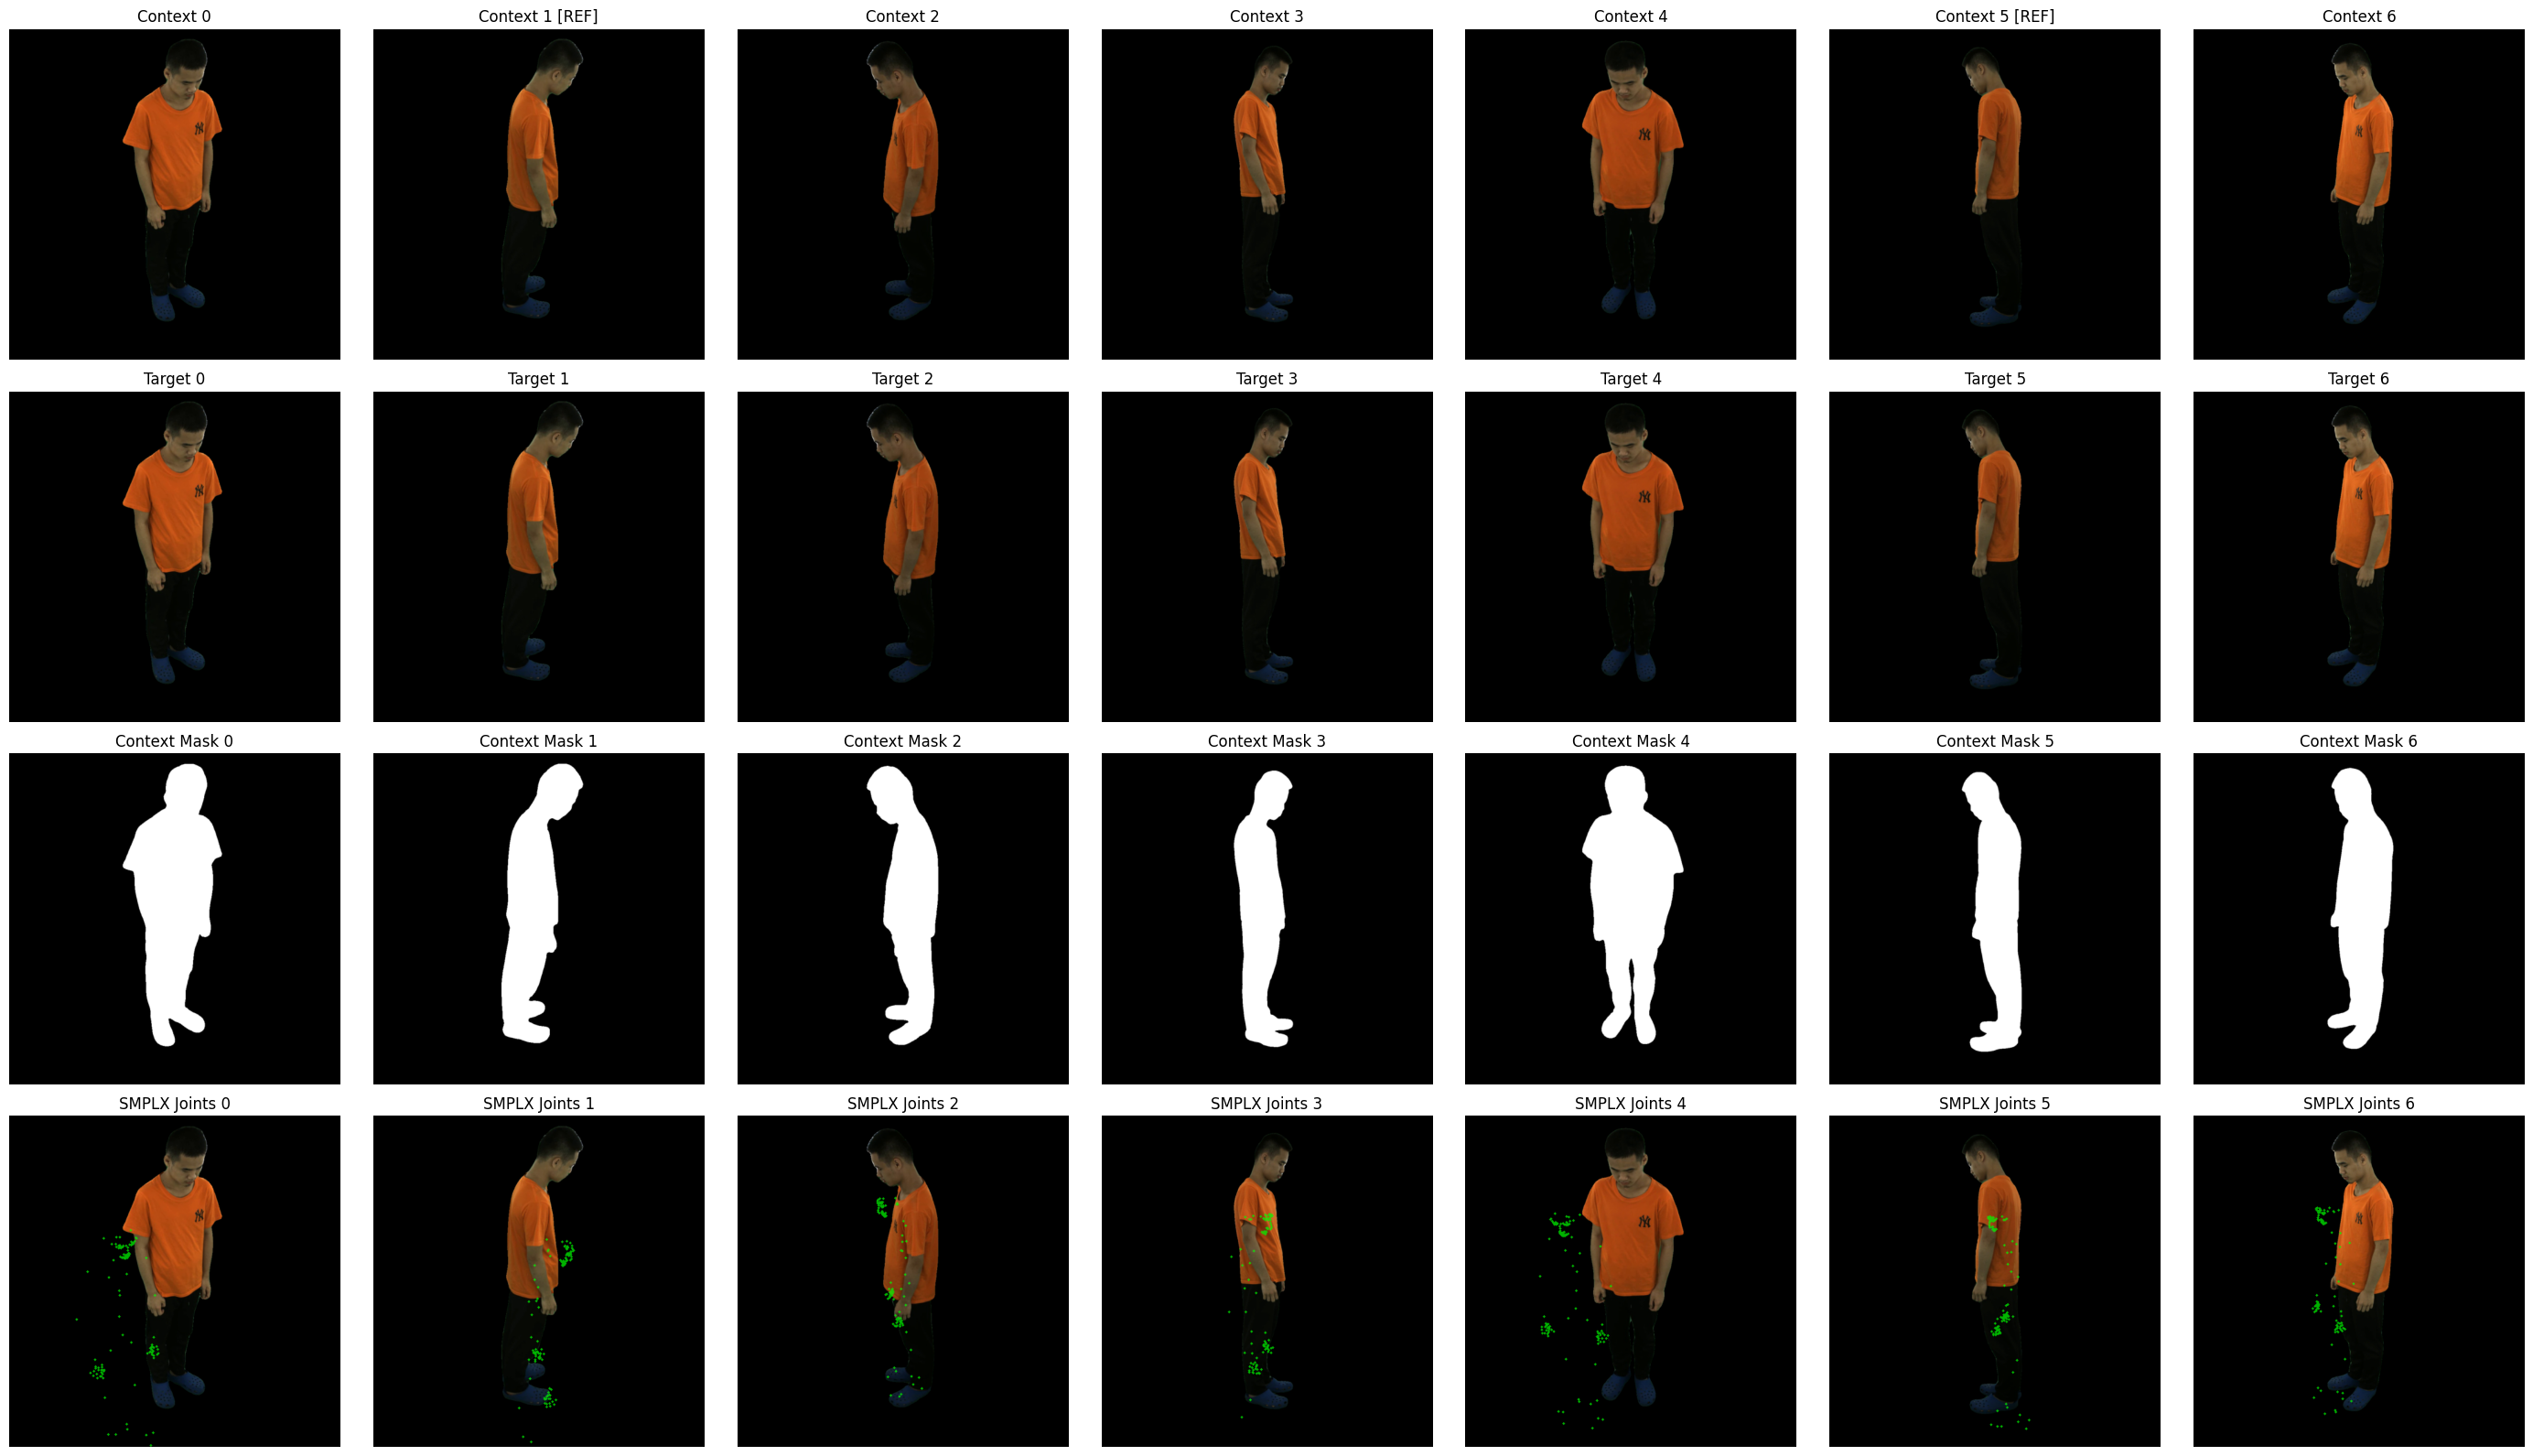

In [62]:
# debug visualization for batch (images, SMPLX, masks, etc.)

import matplotlib.pyplot as plt
import numpy as np
import torch

# For SMPLX projection visualization
from smplx_img_projection import SMPLXProjectionVisualizer

# [1] Get batch context & target
# Note: batch["context"]["image"] has shape [B, N, C, H, W] where B=1
# So we need to squeeze the batch dimension first
context_images = batch["context"]["image"].squeeze(0).detach().cpu()         # [N, 3, H, W]
target_images = batch["target"]["image"].squeeze(0).detach().cpu()           # [N, 3, H, W]
context_masks  = batch["context"]["mask"].squeeze(0).detach().cpu().float()  # [N, H, W]
target_masks   = batch["target"]["mask"].squeeze(0).detach().cpu().float()   # [N, H, W]
ref_mask       = batch["ref_mask"].squeeze(0).detach().cpu().numpy()         # [N]
N = context_images.shape[0]

# For SMPLX projection; important that we use NEUTRAL
# otherwise, we get misalignments.
smplx_model_path = "datasets/smplx/SMPLX_NEUTRAL.npz"

# [2] Collect SMPLX params (should be detached from batch for viz)
smplx_params = batch["target"].get("smplx_params", None)
if smplx_params is None and "smplx_params" in batch:
    smplx_params = batch["smplx_params"]
if isinstance(smplx_params, dict):
    smplx_params_viz = {}
    for k, v in smplx_params.items():
        v = torch.as_tensor(v).detach().cpu()
        if v.ndim == 1:
            v = v.unsqueeze(0)
        smplx_params_viz[k] = v.numpy()
else:
    smplx_params_viz = None

# [3] Camera parameters
# Squeeze batch dimension: [B, N, ...] -> [N, ...]
intrinsics = batch["context"]["intrinsics"].squeeze(0).detach().cpu().numpy()  # [N, 3, 3]
extrinsics = batch["context"]["extrinsics"].squeeze(0).detach().cpu().numpy()  # [N, 4, 4]

fig, axes = plt.subplots(4, N, figsize=(N*4, 16))
border_color = (1, 0, 0)
border_width = 8

for i in range(N):
    # ========== CONTEXT IMAGE ==========
    img = context_images[i]  # Should be [3, H, W] after squeeze(0) above
    # denormalize
    img = img.float().clamp(-1, 1)
    img = (img + 1) * 0.5
    # Ensure img is [3, H, W] - if it's still 4D, squeeze batch dimension
    if img.dim() == 4:
        img = img.squeeze(0)  # Remove batch dimension if present
    # Now img should always be [3, H, W]
    npimg = img.permute(1, 2, 0).numpy()  # [H, W, 3]
    axes[0,i].imshow(npimg)
    axes[0,i].set_title(f'Context {i}' + (' [REF]' if ref_mask[i] else ''))
    axes[0,i].axis('off')
    if ref_mask[i]:
        for spine in axes[0,i].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(border_width)
    else:
        for spine in axes[0,i].spines.values():
            spine.set_edgecolor((0.5,0.5,0.5))
            spine.set_linewidth(1.5)

    # ========== TARGET IMAGE ==========
    timg = target_images[i]  # Should be [3, H, W] after squeeze(0) above
    # denormalize
    timg = timg.float().clamp(-1, 1)
    timg = (timg + 1) * 0.5
    # Ensure timg is [3, H, W] - if it's still 4D, squeeze batch dimension
    if timg.dim() == 4:
        timg = timg.squeeze(0)  # Remove batch dimension if present
    tnpimg = timg.permute(1, 2, 0).numpy()  # [H, W, 3]
    axes[1,i].imshow(tnpimg)
    axes[1,i].set_title(f'Target {i}')
    axes[1,i].axis('off')
    if ref_mask[i]:
        for spine in axes[1,i].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(border_width)
    else:
        for spine in axes[1,i].spines.values():
            spine.set_edgecolor((0.5,0.5,0.5))
            spine.set_linewidth(1.5)

    # ========== MASK ==========
    mask = context_masks[i]
    axes[2,i].imshow(mask, cmap="gray")
    axes[2,i].set_title(f'Context Mask {i}')
    axes[2,i].axis('off')
    if ref_mask[i]:
        for spine in axes[2,i].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(border_width)
    else:
        for spine in axes[2,i].spines.values():
            spine.set_edgecolor((0.5,0.5,0.5))
            spine.set_linewidth(1.5)

    # ========== SMPLX OVERLAY ==========
    try:
        temp_img = (npimg * 255).astype(np.uint8)
        import cv2
        import tempfile
        with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tf:
            img_path = tf.name
            cv2.imwrite(img_path, cv2.cvtColor(temp_img, cv2.COLOR_RGB2BGR))
        # intrinsics: [N, 3, 3], extrinsics: [N, 4, 4]
        this_intr = intrinsics[i]  # [3, 3]
        this_extr = extrinsics[i]  # [4, 4]

        # normalized intrinsics to unnormalized pixel coordinates
        H_img, W_img = npimg.shape[:2]
        # Heuristic: if principal point is <= 1.0, it's normalized (0-1 range)
        if this_intr[0, 2] <= 1.0 and this_intr[1, 2] <= 1.0:
            scale_mat = np.array([
                [W_img, 0, 0],
                [0, H_img, 0],
                [0, 0, 1]
            ])
            this_intr = scale_mat @ this_intr      

        # [1] Create a copy of the params to avoid modifying the batch
        import copy
        viz_params = copy.deepcopy(smplx_params_viz)
        
        # [2] CRITICAL: Zero out translation and global orientation
        # Because 'extrinsics' are already Body-Relative, the body must be at (0,0,0)
        viz_params['transl'] = np.zeros((1, 3))
        viz_params['global_orient'] = np.zeros((1, 3))


        if smplx_params_viz is not None:
            visualizer = SMPLXProjectionVisualizer(smplx_model_path, gender="neutral", use_pca=False, flat_hand_mean=True)
            img_smplx, _ = visualizer.visualize(
                image_path=img_path,
                intrinsics=this_intr,
                extrinsics=this_extr, # Transformed c2w from batch
                smplx_params=viz_params, # Body centered at origin
                show=False,
                draw="joints",
                extrinsics_type="c2w"
            )
            axes[3,i].imshow(img_smplx)
            axes[3,i].set_title(f'SMPLX Joints {i}')
        else:   
            axes[3,i].imshow(npimg)
            axes[3,i].set_title('No SMPLX params')
    except Exception as e:
        axes[3,i].imshow(npimg)
        axes[3,i].set_title(f'SMPLX failed\n{e}')
    axes[3,i].axis('off')

plt.tight_layout()
plt.show()


In [5]:
# CREATE an INPUT DIRECTORY for use in inference script
import os
from PIL import Image
import numpy as np

subject_id = batch["subject_id"][0]
timestep = batch["timestep"][0]
num_images = batch["context"]["image"].shape[1]
# cnl_Rs, cnl_Ts = batch["cnl_Rs"], batch["cnl_Ts"]
# instead, pass through all smplx parameters (these are already converted!)

def denormalize_image(img):
    """
    img: numpy array in shape (C, H, W) with values in [-1, 1]
    returns: numpy array in shape (H, W, C) with values in [0, 1]
    """
    img = img.astype(np.float32).clip(-1, 1)
    img = (img + 1) * 0.5
    # Transpose from (C, H, W) to (H, W, C)
    img = np.transpose(img, (1, 2, 0))
    return img

## initialize directories ## 
# input directory (take the first NUM_INPUT_IMGS images as inputs)
input_dir = f"/workspace/NoPo-Avatar/subject_{subject_id}_{timestep}"
os.makedirs(input_dir, exist_ok=True)
os.makedirs(os.path.join(input_dir, "images"), exist_ok=True)
os.makedirs(os.path.join(input_dir, "masks"), exist_ok=True)

# take the remaining NUM_TEST_IMGS images as test
test_dir = f"/workspace/NoPo-Avatar/subject_{subject_id}_{timestep}/test"
os.makedirs(test_dir, exist_ok=True)
os.makedirs(os.path.join(test_dir, "images"), exist_ok=True)
os.makedirs(os.path.join(test_dir, "masks"), exist_ok=True)
intrinsics = batch['context']["intrinsics"].squeeze(0).numpy() # should be normalized! (8,3,3)
extrinsics = batch['context']["extrinsics"].squeeze(0).numpy() # should be OpenCV c2w! (8,4,4)

# must include reference as an input image, therefore we 'start' from there
order = np.roll(np.arange(num_images), -np.argmax(batch['ref_mask']))
mask_ = np.zeros((num_images,))
mask_[order[:NUM_INPUT_IMGS]] = 1
context_indices = order[mask_ == 1]
test_indices = order[mask_ == 0]

input_K = intrinsics[context_indices]
test_K  = intrinsics[test_indices]
input_c2w = extrinsics[context_indices]
test_c2w  = extrinsics[test_indices]

## all intrinsics and extrinsics already processed, simply save
np.save(os.path.join(input_dir, "intrinsics.npy"), input_K)
np.save(os.path.join(input_dir, "extrinsics.npy"), input_c2w)
np.save(os.path.join(test_dir, "intrinsics.npy"), test_K)
np.save(os.path.join(test_dir, "extrinsics.npy"), test_c2w)

## copy frames + masks over to dirs
for i, is_ref in zip(range(num_images), batch['ref_mask'].flatten()):
    if i < NUM_INPUT_IMGS:
        if is_ref:
            save_path = os.path.join(input_dir, "images", f"{i:06d}_ref.png")
        else:
            save_path = os.path.join(input_dir, "images", f"{i:06d}.png")
    else:
        save_path = os.path.join(test_dir, "images", f"{i:06d}.png")
    
    # Process image
    img = batch['context']['image'][0][i].cpu().numpy()  # Shape: (C, H, W)
    
    if img.shape[0] == 1:
        # single-channel image, duplicate to RGB
        img = np.repeat(img, 3, axis=0)
    elif img.shape[0] != 3:
        raise ValueError(f"Unexpected image shape: {img.shape}, expected (3,H,W) or (1,H,W)")
    
    # Denormalize (returns H, W, C in [0, 1])
    img_denorm = denormalize_image(img)
    
    # Convert to uint8
    img_uint8 = (img_denorm * 255).clip(0, 255).astype(np.uint8)
    Image.fromarray(img_uint8).save(save_path)

    # Process mask - access with batch dimension
    mask_np = batch['context']['mask'][0][i].cpu().numpy()  # Added [0] for batch dimension
    
    # Handle channel dimension
    if mask_np.ndim == 3:
        if mask_np.shape[0] == 1:
            # Shape is (1, H, W) -> squeeze first dimension
            mask_np = mask_np.squeeze(0)
        elif mask_np.shape[2] == 1:
            # Shape is (H, W, 1) -> squeeze last dimension
            mask_np = mask_np.squeeze(2)
        else:
            raise ValueError(f"Unexpected mask shape: {mask_np.shape}")
    
    
    # Convert to uint8 if needed
    if mask_np.dtype != np.uint8:
        mask_np = (mask_np * 255).clip(0, 255).astype(np.uint8)
    
    # Save as grayscale (mode='L')
    Image.fromarray(mask_np, mode='L').save(save_path.replace("images", "masks"))

processed_smplx_json_context = {
    'Rs': batch['context']['Rs'][:, context_indices],
    'Ts': batch['context']['Ts'][:, context_indices],
    'Rs_tpose': batch['context']['Rs_tpose'][:, context_indices],
    'Ts_tpose': batch['context']['Ts_tpose'][:, context_indices],
    'cnl_Rs': batch['context']['cnl_Rs'][:, context_indices],
    'cnl_Ts': batch['context']['cnl_Ts'][:, context_indices],
}

processed_smplx_json_test = {
    'Rs': batch['context']['Rs'][:, test_indices],
    'Ts': batch['context']['Ts'][:, test_indices],
    'Rs_tpose': batch['context']['Rs_tpose'][:, test_indices],
    'Ts_tpose': batch['context']['Ts_tpose'][:, test_indices],
    'cnl_Rs': batch['context']['cnl_Rs'][:, test_indices],
    'cnl_Ts': batch['context']['cnl_Ts'][:, test_indices],
}

## write SMPLX-derived parameters to file
np.save(os.path.join(input_dir, "smplx_params.npy"), processed_smplx_json_context)
np.save(os.path.join(test_dir, "smplx_params.npy"), processed_smplx_json_test)
print(f"Saved output directory to {input_dir}")

Saved output directory to /workspace/NoPo-Avatar/subject_100119_0605


In [6]:
# call the inference script
!python inference.py --input {input_dir} --output {input_dir}_output --render

Using device: cuda
/workspace/NoPo-Avatar/inference.py:329: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location='cpu')
Detected Enc

In [ ]:
# visualize the output
!python visualize_gaussians.py --input {input_dir}_output/gaussians.npz --output {input_dir}_output

Loading /workspace/NoPo-Avatar/subject_104541_1205_output/gaussians.npz...
Loaded 1,671,719 Gaussians

Gaussian Statistics
Number of Gaussians: 1,671,719

Positions (means):
  Range X: [-0.890, 0.868]
  Range Y: [-1.396, 0.465]
  Range Z: [-0.186, 0.185]

Opacities:
  Mean: 0.210
  Std: 0.255
  Range: [0.000, 1.000]
  Visible (>0.5): 238,381 (14.3%)

Scales:
  Mean: 0.0014
  Std: 0.0021
  Range: [0.0003, 0.0431]

Converting covariances to quaternions and scales...
Converting harmonics to RGB...
Saving 1671719 Gaussians to /workspace/NoPo-Avatar/subject_104541_1205_output/gaussians.ply...
/workspace/NoPo-Avatar/visualize_gaussians.py:241: RuntimeWarning: divide by zero encountered in log
  opacity_logit = np.log(opacities[i] / (1 - opacities[i] + 1e-7))
✓ Saved PLY to /workspace/NoPo-Avatar/subject_104541_1205_output/gaussians.ply
Creating 3D visualization...
✓ Saved plot to /workspace/NoPo-Avatar/subject_104541_1205_output/gaussians_3d.png
Figure(1200x1000)

Visualization Complete!

To

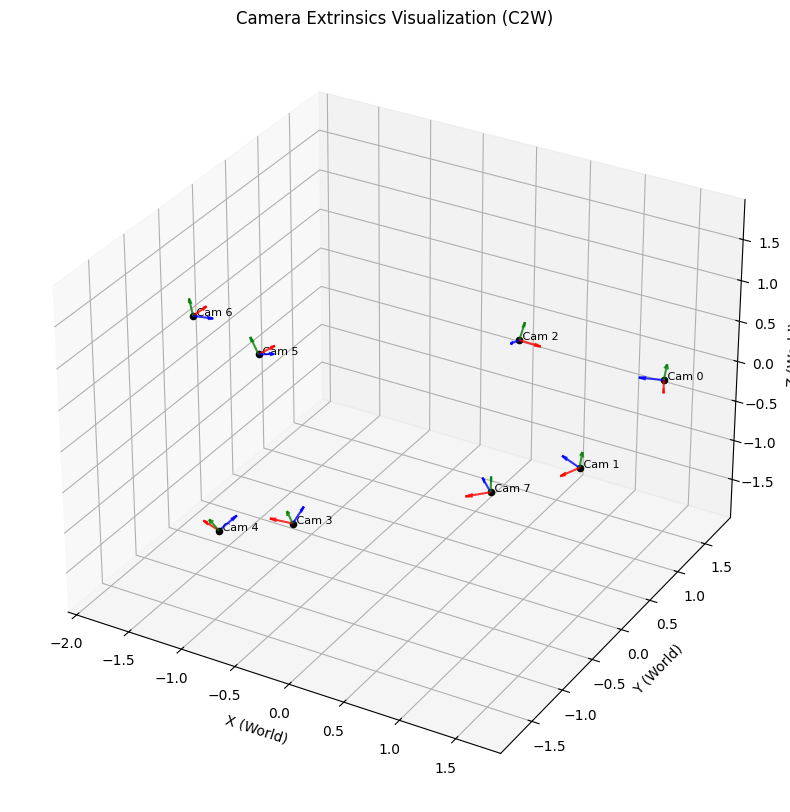

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
from scipy.spatial.transform import Rotation as R

# ==========================================
# 1. SETTINGS & TRANSFORMATION MATRIX
# ==========================================
input_dir = "subject_104544_0305"  # Path to your data

# UPDATE THIS MATRIX TO TRANSFORM THE WHOLE SCENE
# Initially identity. Re-run cell after modifying this.
GLOBAL_TRANSFORM = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
])

# Example: Rotate 90 deg around X if the person is lying flat
# rot = R.from_euler('x', 90, degrees=True).as_matrix()
# GLOBAL_TRANSFORM[:3, :3] = rot

# ==========================================
# 2. LOAD DATA
# ==========================================
extr_path = Path(input_dir) / "extrinsics.npy"
extr_target_path = Path(input_dir) / "test" / "extrinsics.npy"
extrinsics = np.load(extr_path) # Expected shape [N, 4, 4]
extrinsics_target = np.load(extr_target_path) # Expected shape [N, 4, 4]
extrinsics = np.concatenate([extrinsics, extrinsics_target], axis=0)

# ==========================================
# 3. MATPLOTLIB VISUALIZATION
# ==========================================
def visualize_cameras_mpl(poses, transform, axis_length=0.2):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Apply global transform to all poses
    # effective_pose = GLOBAL_TRANSFORM @ pose
    transformed_poses = np.matmul(transform, poses)

    for i, pose in enumerate(transformed_poses):
        pos = pose[:3, 3]
        rot = pose[:3, :3] # Columns are local X, Y, Z in world space

        # Camera Center
        ax.scatter(pos[0], pos[1], pos[2], color='black', s=20)
        ax.text(pos[0], pos[1], pos[2], f" Cam {i}", fontsize=8)

        # Draw RGB Axes (R=X, G=Y, B=Z)
        # X-axis (Right)
        ax.quiver(pos[0], pos[1], pos[2], rot[0, 0], rot[1, 0], rot[2, 0], 
                  length=axis_length, color='red', alpha=0.8)
        # Y-axis (Down in OpenCV)
        ax.quiver(pos[0], pos[1], pos[2], rot[0, 1], rot[1, 1], rot[2, 1], 
                  length=axis_length, color='green', alpha=0.8)
        # Z-axis (Forward in OpenCV)
        ax.quiver(pos[0], pos[1], pos[2], rot[0, 2], rot[1, 2], rot[2, 2], 
                  length=axis_length, color='blue', alpha=0.8)

    # Set labels and equal aspect ratio
    ax.set_xlabel('X (World)')
    ax.set_ylabel('Y (World)')
    ax.set_zlabel('Z (World)')
    ax.set_title('Camera Extrinsics Visualization (C2W)')

    # Improve 3D perspective
    # Determine bounds for equal aspect ratio
    all_pos = transformed_poses[:, :3, 3]
    max_range = np.array([all_pos[:,0].max()-all_pos[:,0].min(), 
                          all_pos[:,1].max()-all_pos[:,1].min(), 
                          all_pos[:,2].max()-all_pos[:,2].min()]).max() / 2.0

    mid_x = (all_pos[:,0].max()+all_pos[:,0].min()) * 0.5
    mid_y = (all_pos[:,1].max()+all_pos[:,1].min()) * 0.5
    mid_z = (all_pos[:,2].max()+all_pos[:,2].min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    plt.show()

# Execute
visualize_cameras_mpl(extrinsics, GLOBAL_TRANSFORM)